# Sales Prediction Using Machine Learning    

## Objective   

In this project, I analyzed how TV, Radio, and Newspaper advertising influence product sales. I trained and compared three regression models to determine which one provides the most accurate sales predictions.

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
# Loading the dataset

df = pd.read_csv("D:/CodeSoft/advertising.csv")

# Display first 5 rows
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
# Shape of dataset
print("Rows and Columns :", df.shape)

Rows and Columns : (200, 4)


In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
# Missing values
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [8]:
# Statistical summary
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [10]:
# Checking duplicate values
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [11]:
# Remove duplicates if present
df = df.drop_duplicates()
print(df.shape)

(200, 4)


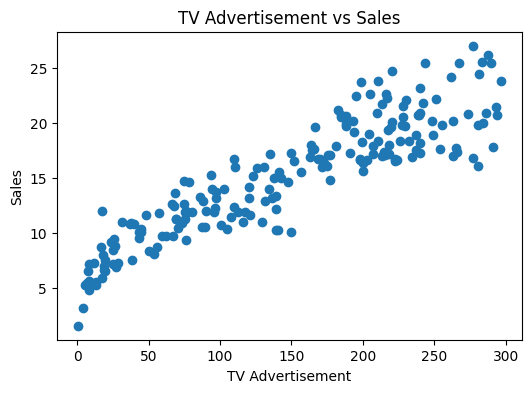

In [12]:
# Scatter plot between TV and Sales

plt.figure(figsize=(6,4))
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Advertisement")
plt.ylabel("Sales")
plt.title("TV Advertisement vs Sales")
plt.show()

### Analysis:-   
From this graph, we can see that there is a positive relationship between TV advertising and sales. As the amount spent on TV advertisements increases, sales also tend to increase. Most of the points follow an upward trend, although there are a few exceptions. This shows that TV advertising plays an important role in improving product sales.


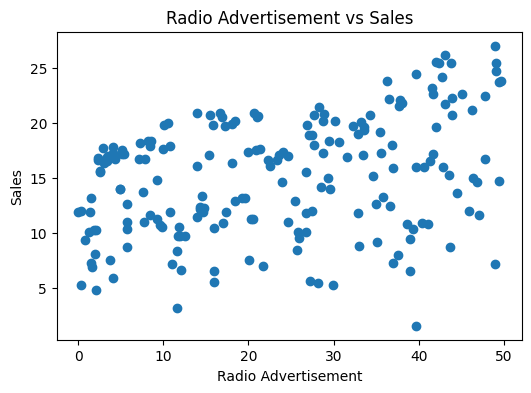

In [14]:
# Scatter plot for Radio

plt.figure(figsize=(6,4))
plt.scatter(df["Radio"], df["Sales"])
plt.xlabel("Radio Advertisement")
plt.ylabel("Sales")
plt.title("Radio Advertisement vs Sales")
plt.show()

### Analysis:-    
This graph also shows a positive relationship between Radio advertising and sales, but it is not as strong as TV advertising. The points are more spread out, which means the increase in sales is not always consistent. Radio advertisements still have a positive effect on sales, but they may work better when used along with other advertising methods.


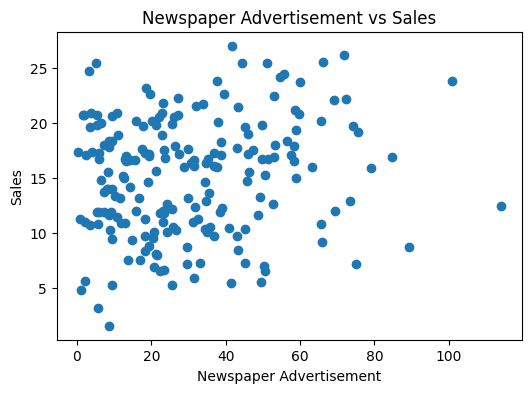

In [15]:
# Scatter plot for Newspaper

plt.figure(figsize=(6,4))
plt.scatter(df["Newspaper"], df["Sales"])
plt.xlabel("Newspaper Advertisement")
plt.ylabel("Sales")
plt.title("Newspaper Advertisement vs Sales")
plt.show()

### Analysis:-
Compared to TV and Radio, Newspaper advertising has a much weaker relationship with sales. The data points are scattered and do not show a clear pattern. This suggests that spending more on Newspaper advertisements does not always lead to higher sales. Therefore, Newspaper advertising has less impact on predicting sales.


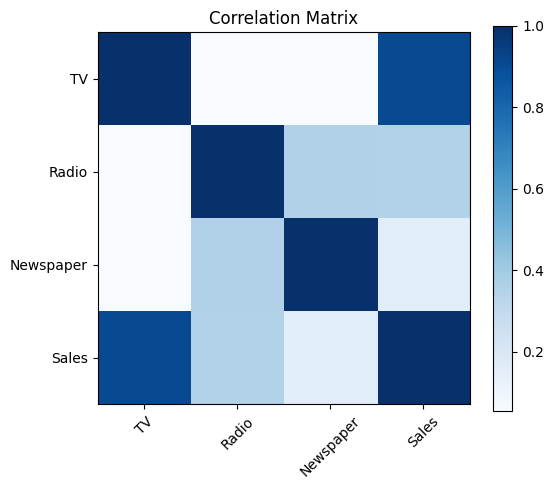

In [22]:
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='Blues')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

### Analysis:-
The correlation matrix helps us understand how the different features are related to each other. It shows that TV has the highest correlation with Sales, followed by Radio. Newspaper has the lowest correlation, which means it has less influence on sales. These results are similar to what we observed in the scatter plots.

In [23]:
X = df.drop("Sales", axis=1)

y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(160, 3)
(40, 3)


In [24]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression
MAE : 1.2748262109549338
RMSE : 1.7052146229349223
R2 Score : 0.9059011844150826


In [25]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score :", r2_score(y_test, dt_pred))

Decision Tree
MAE : 1.24
RMSE : 1.8444511378727275
R2 Score : 0.8899068317956319


In [26]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest
MAE : 0.9179999999999993
RMSE : 1.1989298770153327
R2 Score : 0.9534827934927883


In [27]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.905901
1,Decision Tree,0.889907
2,Random Forest,0.953483


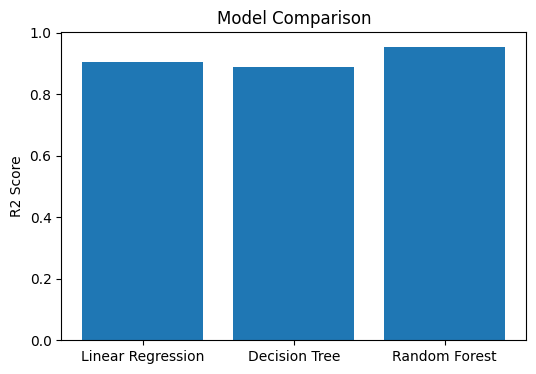

In [28]:
plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["R2 Score"])

plt.title("Model Comparison")
plt.ylabel("R2 Score")

plt.show()

### Analysis:-    
This graph compares the performance of all three regression models using their R² scores. Random Forest achieved the highest score, which means it made the most accurate predictions. Linear Regression also performed well, while Decision Tree had the lowest score among the three models. Based on these results, Random Forest was selected as the best model for this project.

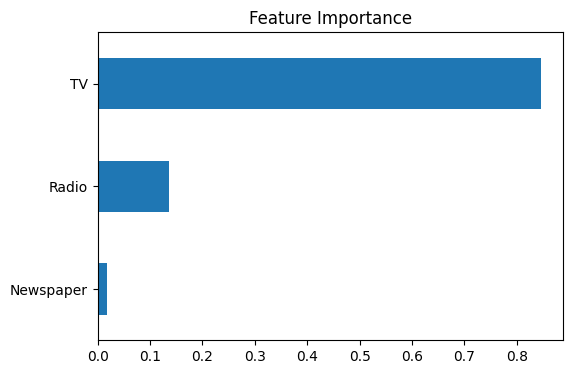

In [29]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(6,4)
)

plt.title("Feature Importance")
plt.show()

### Analysis:-   
The feature importance graph shows which advertising platform contributes the most to predicting sales. TV has the highest importance, followed by Radio. Newspaper has the lowest importance, which means it has very little effect on the model's predictions. This indicates that TV advertising is the most useful feature for predicting sales.

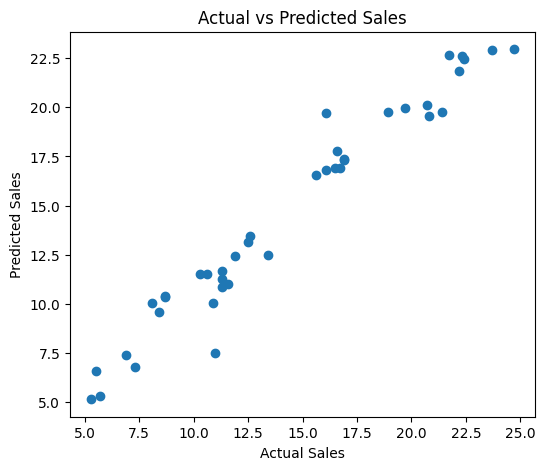

In [30]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

### Analysis:-   
This graph compares the actual sales values with the values predicted by the Random Forest model. Most of the points are close to each other, showing that the model predicts sales quite accurately. Although there are a few prediction errors, the overall results show that the model performs well on the test data.

### Conclusion:-

In this project, I built and compared three machine learning models to predict product sales based on TV, Radio, and Newspaper advertising data. Before training the models, I explored the dataset using different visualizations to understand the relationship between advertising and sales.

After comparing the models, Random Forest gave the best performance with the highest R² score and the lowest prediction error. The feature importance graph also showed that TV advertising has the greatest impact on sales, while Newspaper advertising contributes the least.

Through this project, I gained practical experience in data preprocessing, data visualization, regression models, and model evaluation. It also helped me understand how machine learning can be used to support better business and marketing decisions.